In [1]:
import pandas as pd

# Reading the data from the specified path
df = pd.read_csv('Social_Network_Ads.csv')

In [2]:
# Displaying the first 5 rows of the dataset
print("First 5 rows:")
print(df.head())

# Displaying the last 5 rows of the dataset
print("\nLast 5 rows:")
print(df.tail())

# Getting a summary of the dataset (columns, data types, null values)
print("\nDataset Info:")
print(df.info())

# Statistical summary of the numerical columns
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Last 5 rows:
      User ID  Gender  Age  EstimatedSalary  Purchased
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400

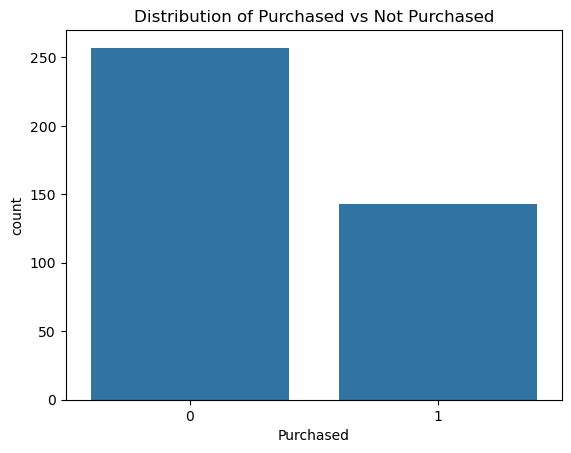

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the distribution of the target variable
# 0: Not Purchased, 1: Purchased
sns.countplot(x='Purchased', data=df)
plt.title('Distribution of Purchased vs Not Purchased')
plt.show()

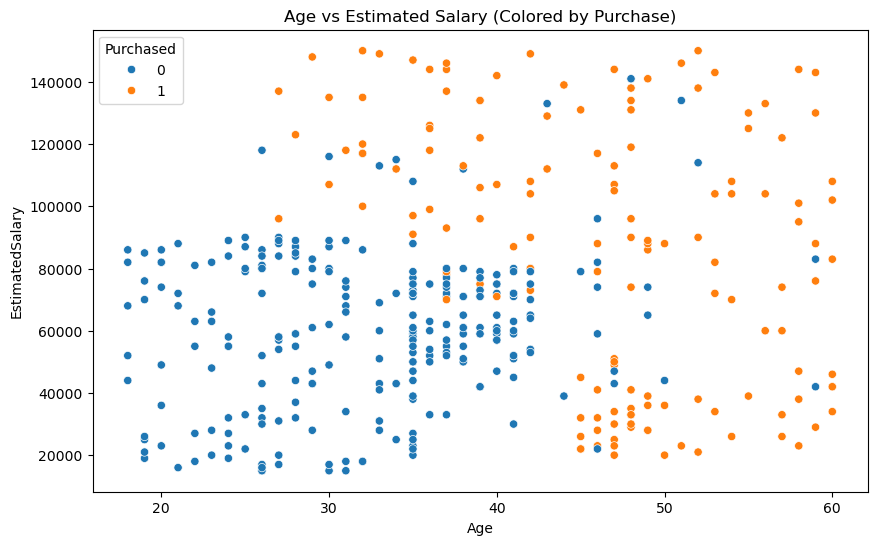

In [4]:
# Correlation between Age, Salary and Purchasing decision
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df)
plt.title('Age vs Estimated Salary (Colored by Purchase)')
plt.show()

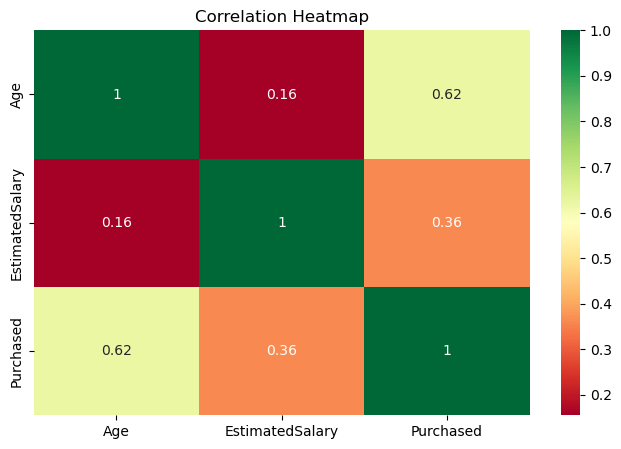

In [5]:
# Heatmap to see correlations between variables
# We drop non-numeric columns like 'Gender' for this plot
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(['Gender', 'User ID'], axis=1).corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

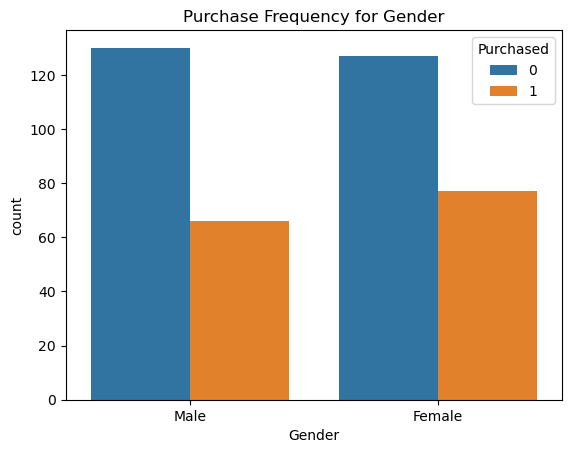

Purchase rates by gender:
Gender
Female    0.377451
Male      0.336735
Name: Purchased, dtype: float64


In [6]:
# Comparing purchasing habits between Genders
sns.countplot(x='Gender', hue='Purchased', data=df)
plt.title('Purchase Frequency for Gender')
plt.show()

# Calculating the exact percentages to be sure
print("Purchase rates by gender:")
print(df.groupby('Gender')['Purchased'].mean())

In [7]:
# Create Data1: Drop User ID and Map Gender (Female: 1, Male: 0)
data1 = df.drop(['User ID'], axis=1).copy()
data1['Gender'] = data1['Gender'].map({'Female': 1, 'Male': 0})

# Create Data2: Drop both User ID and Gender (Only Age and Salary)
data2 = df.drop(['User ID', 'Gender'], axis=1)

# Let's verify our hard work
print("Data1 Preview (Female=1, Male=0):")
print(data1.head())

print("\nData2 Preview (No Gender):")
print(data2.head())

Data1 Preview (Female=1, Male=0):
   Gender  Age  EstimatedSalary  Purchased
0       0   19            19000          0
1       0   35            20000          0
2       1   26            43000          0
3       1   27            57000          0
4       0   19            76000          0

Data2 Preview (No Gender):
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [8]:
!pip install lazypredict

In [9]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# --- PREPARING DATA 1 (With Gender: Female=1, Male=0) ---
X1 = data1.drop(['Purchased'], axis=1).values
y1 = data1['Purchased'].values

# --- PREPARING DATA 2 (Only Age and Salary) ---
X2 = data2.drop(['Purchased'], axis=1).values
y2 = data2['Purchased'].values

# --- SPLITTING BOTH DATASETS ---
# Using random_state=0 to ensure we compare apples to apples
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.25, random_state=0)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=0)

# --- RUNNING LAZY PREDICT FOR DATA 1 ---
clf1 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models1, predictions1 = clf1.fit(X1_train, X1_test, y1_train, y1_test)

# --- RUNNING LAZY PREDICT FOR DATA 2 ---
clf2 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models2, predictions2 = clf2.fit(X2_train, X2_test, y2_train, y2_test)

print("\n--- WINNERS OF DATA 1 (WITH GENDER) ---")
print(models1.head(10))

print("\n--- WINNERS OF DATA 2 (NO GENDER) ---")
print(models2.head(10))

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 111, number of negative: 189
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 112
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370000 -> initscore=-0.532217
[LightGBM] [Info] Start training from score -0.532217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 111, number of negative: 189
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 109
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370000 -> initscore=-0.532217
[LightGBM] [Info] Start training from score -0.532217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Feature Scaling (KNN is distance-based, so this is mandatory!)
sc = StandardScaler()
X2_train_scaled = sc.fit_transform(X2_train)
X2_test_scaled = sc.transform(X2_test)

# 2. Initializing KNN with standard parameters (k=5)
# metric='minkowski' and p=2 makes it Euclidean Distance
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# 3. Training the model
classifier.fit(X2_train_scaled, y2_train)

# 4. Predicting the Test set results
y_pred = classifier.predict(X2_test_scaled)

# 5. Evaluation
print(f"Accuracy Score: {accuracy_score(y2_test, y_pred)}")

Accuracy Score: 0.93


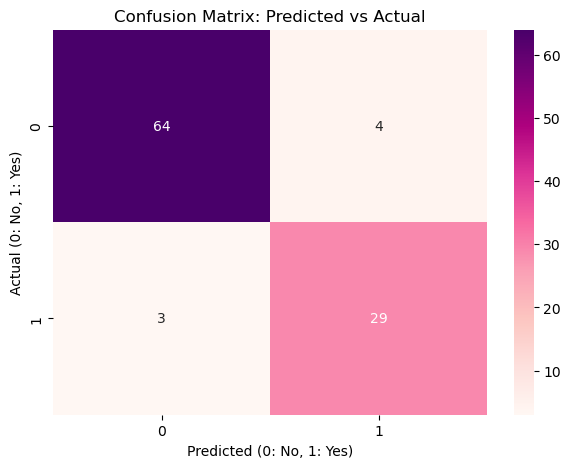

Correct Predictions: 93
Wrong Predictions: 7


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Building the Confusion Matrix
cm = confusion_matrix(y2_test, y_pred)

# Visualizing with a nice Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu') # Using a different color palette
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted (0: No, 1: Yes)')
plt.ylabel('Actual (0: No, 1: Yes)')
plt.show()

# Detailed breakdown
print(f"Correct Predictions: {cm[0][0] + cm[1][1]}")
print(f"Wrong Predictions: {cm[0][1] + cm[1][0]}")

In [12]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

# 1. Classification Report (Precision, Recall, F1)
print("--- Detailed Classification Report ---")
print(classification_report(y2_test, y_pred, target_names=['Not Purchased', 'Purchased']))

# 2. Training vs Test Scores (Checking for Overfitting)
train_accuracy = classifier.score(X2_train_scaled, y2_train)
test_accuracy = accuracy_score(y2_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")

# 3. K-Fold Cross Validation (Stability Check)
# We split the data into 10 parts and test the model 10 times
accuracies = cross_val_score(estimator=classifier, X=X2_train_scaled, y=y2_train, cv=10)
print("\n--- Cross Validation (10-Fold) ---")
print(f"Average Accuracy: {accuracies.mean():.4f}")
print(f"Standard Deviation: {accuracies.std():.4f}")

--- Detailed Classification Report ---
               precision    recall  f1-score   support

Not Purchased       0.96      0.94      0.95        68
    Purchased       0.88      0.91      0.89        32

     accuracy                           0.93       100
    macro avg       0.92      0.92      0.92       100
 weighted avg       0.93      0.93      0.93       100

Training Accuracy: 0.9100
Test Accuracy: 0.9300
Difference: 0.0200

--- Cross Validation (10-Fold) ---
Average Accuracy: 0.9067
Standard Deviation: 0.0663


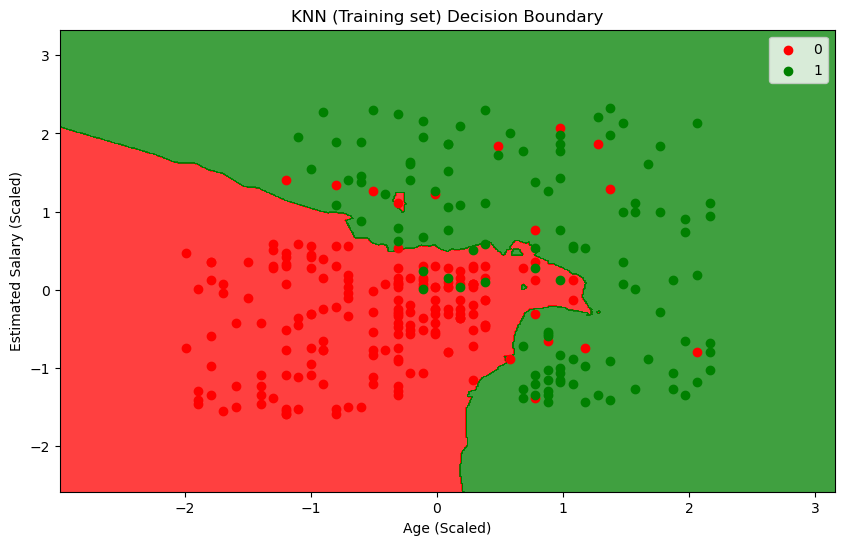

In [13]:
import numpy as np 
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# We use the scaled Training set for visualization
X_set, y_set = X2_train_scaled, y2_train

# Creating a mesh grid to color the entire area
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.figure(figsize=(10, 6))
# Bu satır arka planı tahminlere göre renklendirir
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plotting the actual points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

plt.title('KNN (Training set) Decision Boundary')
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.legend()
plt.show()

# Social Network Ads - Purchase Prediction Analysis

## 📊 Project Overview
This project aims to predict whether a user will purchase a product based on their demographic information (Age, Gender, and Estimated Salary). We implemented and evaluated a **K-Nearest Neighbors (KNN)** classifier and compared its performance with various machine learning models using **Lazy Predict**.

## 🛠️ Data Processing & Methodology
* **Feature Selection:** We tested two scenarios:
    * **Scenario 1:** Age, Salary, and Gender (Encoded: Female=1, Male=0).
    * **Scenario 2:** Age and Salary only (Selected for final model due to efficiency).
* **Preprocessing:** Features were scaled using `StandardScaler` to ensure the distance-based KNN algorithm performs optimally.
* **Validation:** A 75/25 Train-Test split was used, followed by **10-Fold Cross-Validation** to ensure model stability.

## 🚀 Model Performance (KNN)
The model achieved high accuracy and demonstrated robust generalization on unseen data.

| Metric | Score |
| :--- | :--- |
| **Test Accuracy** | **93.00%** |
| **Training Accuracy** | **91.00%** |
| **10-Fold CV Mean** | **90.67%** |
| **F1-Score (Purchased)** | **0.89** |
| **F1-Score (Not Purchased)** | **0.95** |

### Detailed Classification Report:
```text
               precision    recall  f1-score   support
Not Purchased       0.96      0.94      0.95        68
    Purchased       0.88      0.91      0.89        32